In [1]:
import pandas as pd 
from tabulate import tabulate
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import re

In [2]:
files = "../dataset_features/all_fn.csv"
all_files="../dataset_features/files_raw.csv"
source = "../backups/exp_no_hist.csv"
names = ["Vibecoding", "SideProject"]

In [3]:
files_df = pd.read_csv(files)
files_df.drop_duplicates(inplace=True)
source_df = pd.read_csv(source, index_col=0)
source_df.drop_duplicates(inplace=True)

In [4]:


files_df =files_df.rename(columns={'Unnamed: 0': 'url', 'url': 'commit', 'commit':'proj_name', 'proj_name': 'file_path', 'file_path':'file_name', 'file_name': 'fn_name', 'fn_name': 'fn_sig', 'fn_sig':'line_count', 'line_count':'fn_called', 'fn_called':'var_list', 'var_list':'fn_code', 'fn_code':'NaN'})

In [5]:
files_df.head()

,url,commit,proj_name,file_path,file_name,fn_name,fn_sig,line_count,n_args,fn_called,var_list,fn_code,NaN,is_async
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_exercise,def verify_exercise(user_state: UserState) -> ...,1,5,"['exercises.get(user_state.exercise_name, None...",['exercise'],def verify_exercise(user_state: UserState) -> ...,False,NaN
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_required,"def verify_required(exercise: Exercise, _: Use...",2,8,"[""current_app.logger.info(f'exercise.requires_...",['requires_exercise'],"def verify_required(exercise: Exercise, _: Use...",False,NaN
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_command_regex,"def verify_command_regex(exercise: Exercise, u...",2,7,"[""current_app.logger.info(f'exercise.command_r...",['command_match'],"def verify_command_regex(exercise: Exercise, u...",False,NaN
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_output_regex,"def verify_output_regex(exercise: Exercise, us...",2,7,"[""current_app.logger.info(f'exercise.command_r...",['output_match'],"def verify_output_regex(exercise: Exercise, us...",False,NaN
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_filesystem_conditions,def verify_filesystem_conditions(exercise: Exe...,2,26,"[""os.path.join('/home/anubis', filesystem_cond...","['path', 'exists', 'isdir', 'content', 'conten...",def verify_filesystem_conditions(exercise: Exe...,False,NaN


In [6]:
def make_mask(df_source, df_files, name):  
    mask = (df_source[name])
    name_df = df_source[mask]
    url_set = set(name_df["url"])
    mask = (df_files["url"].isin(url_set))
    masked_files = df_files[mask]
    return masked_files

In [7]:
df_vc = make_mask(source_df, files_df, names[0])
df_sp = make_mask(source_df, files_df, names[1])

In [8]:
df_vc.head()

,url,commit,proj_name,file_path,file_name,fn_name,fn_sig,line_count,n_args,fn_called,var_list,fn_code,NaN,is_async
39534,https://github.com/mk-knight23/vibe-cli,2e72caea6100374221fb0210c521412cdf5a61c5,vibe-cli,vibe-cli/.claude/skills/continuous-learning-v2...,instinct-cli.py,parse_instinct_file,def parse_instinct_file(content: str) -> list[...,1,37,"[""content.split('\\n')"", ""'\\n'.join(content_l...","['instincts', 'current', 'in_frontmatter', 'co...",def parse_instinct_file(content: str) -> list[...,False,NaN
39535,https://github.com/mk-knight23/vibe-cli,2e72caea6100374221fb0210c521412cdf5a61c5,vibe-cli,vibe-cli/.claude/skills/continuous-learning-v2...,instinct-cli.py,load_all_instincts,def load_all_instincts() -> list[dict]:,0,17,"[""directory.glob('*.yaml')"", 'directory.exists...","['instincts', 'content', 'parsed', ""inst['_sou...","def load_all_instincts() -> list[dict]:\n ""...",False,NaN
39536,https://github.com/mk-knight23/vibe-cli,2e72caea6100374221fb0210c521412cdf5a61c5,vibe-cli,vibe-cli/.claude/skills/continuous-learning-v2...,instinct-cli.py,cmd_status,def cmd_status(args):,1,44,"['load_all_instincts()', 'defaultdict(list)', ...","['instincts', 'by_domain', 'personal', 'inheri...","def cmd_status(args):\n """"""Show status of a...",False,NaN
39537,https://github.com/mk-knight23/vibe-cli,2e72caea6100374221fb0210c521412cdf5a61c5,vibe-cli,vibe-cli/.claude/skills/continuous-learning-v2...,instinct-cli.py,cmd_import,def cmd_import(args):,1,89,"['parse_instinct_file(content)', ""print(f'\\nF...","['source', 'new_instincts', 'existing', 'exist...","def cmd_import(args):\n """"""Import instincts...",False,NaN
39538,https://github.com/mk-knight23/vibe-cli,2e72caea6100374221fb0210c521412cdf5a61c5,vibe-cli,vibe-cli/.claude/skills/continuous-learning-v2...,instinct-cli.py,cmd_export,def cmd_export(args):,1,31,"['load_all_instincts()', ""print('No instincts ...","['instincts', 'output', 'value']","def cmd_export(args):\n """"""Export instincts...",False,NaN


In [41]:
print(f"number vibecoded projects with functions: {len(df_vc.url.unique())}")
print(f"number sideproject projects with functions: {len(df_sp.url.unique())}")
print(f"number vibecoded files with functions: {len(df_vc.file_path.unique())}")
print(f"number sideproject files with functions: {len(df_sp.file_path.unique())}")

number vibecoded projects with functions: 168
number sideproject projects with functions: 145
number vibecoded files with functions: 10196
number sideproject files with functions: 3871


In [ ]:
df_sp["source"] = "SideProject"
df_vc["source"] = "Vibecoding"

df_all = pd.concat([df_sp, df_vc], ignore_index=True)
df_all.head() 

,url,commit,proj_name,file_path,file_name,fn_name,fn_sig,line_count,n_args,fn_called,var_list,fn_code,NaN,is_async,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_exercise,def verify_exercise(user_state: UserState) -> ...,1,5,"['exercises.get(user_state.exercise_name, None...",['exercise'],def verify_exercise(user_state: UserState) -> ...,False,NaN,SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_required,"def verify_required(exercise: Exercise, _: Use...",2,8,"[""current_app.logger.info(f'exercise.requires_...",['requires_exercise'],"def verify_required(exercise: Exercise, _: Use...",False,NaN,SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_command_regex,"def verify_command_regex(exercise: Exercise, u...",2,7,"[""current_app.logger.info(f'exercise.command_r...",['command_match'],"def verify_command_regex(exercise: Exercise, u...",False,NaN,SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_output_regex,"def verify_output_regex(exercise: Exercise, us...",2,7,"[""current_app.logger.info(f'exercise.command_r...",['output_match'],"def verify_output_regex(exercise: Exercise, us...",False,NaN,SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_filesystem_conditions,def verify_filesystem_conditions(exercise: Exe...,2,26,"[""os.path.join('/home/anubis', filesystem_cond...","['path', 'exists', 'isdir', 'content', 'conten...",def verify_filesystem_conditions(exercise: Exe...,False,NaN,SideProject


In [10]:
df_all.source.value_counts()

source
Vibecoding     109143
SideProject     38671
Name: count, dtype: int64

In [11]:
all_files_df = pd.read_csv(all_files, index_col=0)
all_files_df.drop_duplicates(inplace=True)

all_files_py = all_files_df[all_files_df["extn"] == "py"]

py_vc = make_mask(source_df, all_files_py, names[0])
py_sp = make_mask(source_df, all_files_py, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"

py_all = pd.concat([py_sp, py_vc], ignore_index=True)
py_all

/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_75010/195636509.py:1: DtypeWarning: Columns (0: url, 1: lines) have mixed types. Specify dtype option on import or set low_memory=False.
  all_files_df = pd.read_csv(all_files, index_col=0)


,url,proj_name,full_path,file_name,extn,lines,blank_lines,n_characters,source
0,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/manage.py,manage.py,py,22,4,508.0,SideProject
1,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/models.py,models.py,py,50,14,1168.0,SideProject
2,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/__init_...,__init__.py,py,0,0,0.0,SideProject
3,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/apps.py,apps.py,py,6,2,136.0,SideProject
4,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/admin.py,admin.py,py,9,4,202.0,SideProject
...,...,...,...,...,...,...,...,...,...
17613,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/__i...,__init__.py,py,48,8,1494.0,Vibecoding
17614,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sys...,system_management_service.py,py,423,80,11348.0,Vibecoding
17615,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/bas...,base_service.py,py,140,31,2629.0,Vibecoding
17616,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/cod...,code_intelligence_service.py,py,245,43,5991.0,Vibecoding


In [12]:

df_path=df_all.groupby(["file_path", "source"]).size().reset_index(name="n_fns")
df_path

,file_path,source,n_fns
0,AI-Code-Executor/backend/anthropic_client.py,Vibecoding,4
1,AI-Code-Executor/backend/code_executor.py,Vibecoding,8
2,AI-Code-Executor/backend/database.py,Vibecoding,2
3,AI-Code-Executor/backend/gemini_client.py,Vibecoding,2
4,AI-Code-Executor/backend/lmstudio_client.py,Vibecoding,5
...,...,...,...
14062,yaat/yaat/staticfiles.py,SideProject,8
14063,yaat/yaat/templating.py,SideProject,6
14064,yaat/yaat/websockets.py,SideProject,15
14065,youtube-sampler/api/app/app.py,SideProject,9


In [13]:
df_path.groupby("source").n_fns.mean()

source
SideProject     9.989925
Vibecoding     10.704492
Name: n_fns, dtype: float64

In [14]:
all_py_files_list = py_all["full_path"]
all_py_source = py_all["source"]
py_with_fns = set(df_path["file_path"])
for file, source in zip(all_py_files_list, all_py_source):
    if file in py_with_fns:
        continue
    else:
        df_path.loc[len(df_path)] = [file, source, 0]

In [15]:
print(f"number of zeros total: {len(df_path.index[df_path['n_fns'] == 0].tolist())}")
print(f"number of vibecoding zeros: {len(df_path.index[(df_path['n_fns'] == 0) & (df_path['source'] == "Vibecoding")].tolist())}")
print(f"number of sideproject zeros: {len(df_path.index[(df_path['n_fns'] == 0) & (df_path['source'] == "SideProject")].tolist())}")

number of zeros total: 3551
number of vibecoding zeros: 2361
number of sideproject zeros: 1190


In [16]:
#need to remove one outlier from sideproject, there's one with 6,000 fns
print(len(df_path))


df = df_path[(df_path['n_fns'] > -1) & (df_path['n_fns'] < 2000)]
print(len(df))


17618
17617


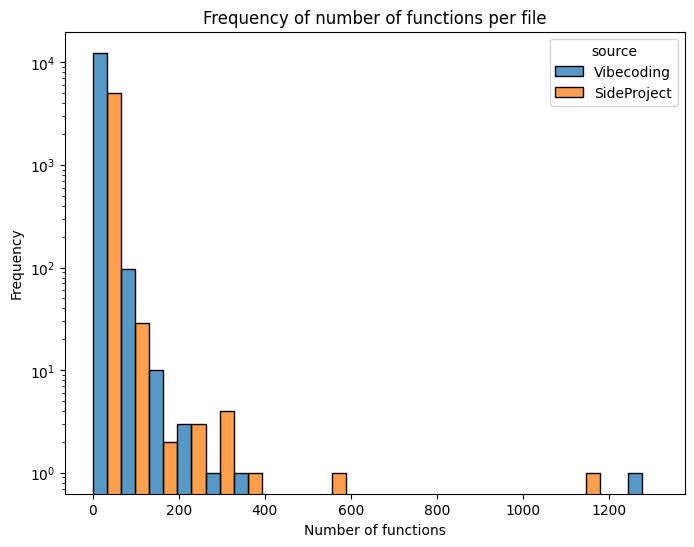

In [42]:
plt.figure(figsize=(8,6))
sns.histplot(
    data=df,
    x="n_fns",
    hue="source", 
    multiple="dodge",
    bins = 20,
    # kind="boxen",
    # log_scale=True,
    # height=10, 
    # aspect=1,
) #there is something wrong here
plt.yscale("log")
plt.title(f"Frequency of number of functions per file")
plt.ylabel("Frequency")
plt.xlabel("Number of functions")
plt.show()

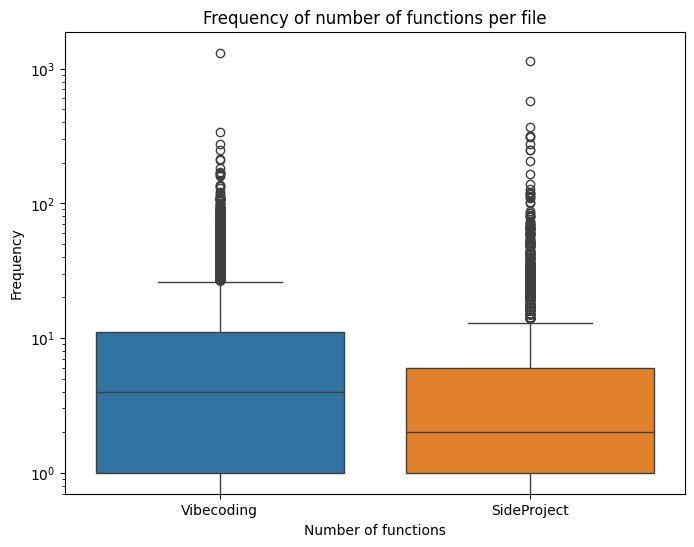

In [48]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    y="n_fns",
    x="source",
    hue="source", 
    # multiple="dodge",
    # bins = 20,
    # kind="boxen",
    # log_scale=True,
    # height=10, 
    # aspect=1,
) #there is something wrong here
plt.yscale("log")
plt.title(f"Frequency of number of functions per file")
plt.ylabel("Frequency")
plt.xlabel("Number of functions")
plt.show()

Text(0.5, 0, 'Number of functions')

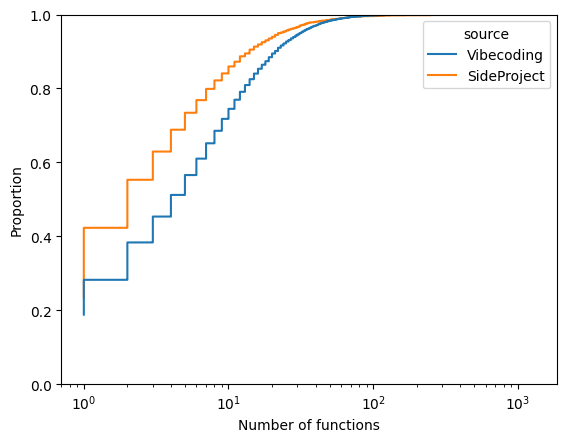

In [49]:
sns.ecdfplot(data=df,
    x="n_fns",
    hue="source", stat="proportion", log_scale=True)
plt.xlabel("Number of functions")

In [19]:
df_large = df_path[(df_path['n_fns'] > 250) ] #& (df_path['n_fns'] < 1000)
print(len(df_large["file_path"]))
print(df_large["file_path"].iloc[5])

11
gsoc-tagger/env/Lib/site-packages/setuptools/_vendor/pyparsing.py


Outliers:

Outlier >250 5


gsoc-tagger/env/Lib/site-packages/pip/_vendor/html5lib/html5parser.py

gsoc-tagger/env/Lib/site-packages/pip/_vendor/pyparsing.py

gsoc-tagger/env/Lib/site-packages/pkg_resources/_vendor/pyparsing.py

gsoc-tagger/env/Lib/site-packages/setuptools/_vendor/pyparsing.py

gsoc-tagger/env/Lib/site-packages/werkzeug/datastructures.py


Outlier >500 1

same project as before (we should really just remove this project)


Outlier >1000 1

also from same project as 6,000 one (I think we should just remove this project)

Outlier >6,000 1 (verified is a sideproject) (verified that there's a LOT):
https://raw.githubusercontent.com/cermatej/plsql-analysis/refs/heads/master/src/rest/parser_api/parser/antlr_plsql/antlr_py/plsqlParser.py




In [20]:
df.groupby("source").n_fns.mean()

source
SideProject    6.340711
Vibecoding     8.691805
Name: n_fns, dtype: float64

In [21]:
df.groupby("source").n_fns.sum()

source
SideProject     32084
Vibecoding     109143
Name: n_fns, dtype: int64

In [22]:
df.groupby("source").n_fns.value_counts().get("Vibecoding")

n_fns
0       2361
2       1269
1       1183
3        880
4        735
        ... 
136        1
111        1
71         1
212        1
1310       1
Name: count, Length: 122, dtype: int64

## Getting files with no functions url

In [23]:
py_all.head()

,url,proj_name,full_path,file_name,extn,lines,blank_lines,n_characters,source
0,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/manage.py,manage.py,py,22,4,508.0,SideProject
1,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/models.py,models.py,py,50,14,1168.0,SideProject
2,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/__init_...,__init__.py,py,0,0,0.0,SideProject
3,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/apps.py,apps.py,py,6,2,136.0,SideProject
4,https://github.com/ctk-hq/ctk,ctk,ctk/services/backend/src/organizations/admin.py,admin.py,py,9,4,202.0,SideProject


In [24]:
i_source = source_df.set_index("url")
i_source.head()

,commit,error,time_out,SideProject,Vibecoding
url,,,,,
https://github.com/Skowt/Loadr,c2ead4af6a33aed6ed79684f2346de6a3f12fe5a,False,False,True,False
https://github.com/AI-Spawn/Save-The-Turtles,4747b9d40aeb6c1cbc73eb0802008c4afff686d9,False,False,True,False
https://github.com/YigitGunduc/cycle,26eb2a3b4b61505b7f21395e0165a1cee3973090,False,False,True,False
https://github.com/saurabh0719/jett,3f57c4a8a626678f27305c54d13237eb583c30b4,False,False,True,False
https://github.com/tn/climood,4dae3cae768245a169e8abeccb457558fac8c112,False,False,True,False


In [25]:
df_all.head()

,url,commit,proj_name,file_path,file_name,fn_name,fn_sig,line_count,n_args,fn_called,var_list,fn_code,NaN,is_async,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_exercise,def verify_exercise(user_state: UserState) -> ...,1,5,"['exercises.get(user_state.exercise_name, None...",['exercise'],def verify_exercise(user_state: UserState) -> ...,False,NaN,SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_required,"def verify_required(exercise: Exercise, _: Use...",2,8,"[""current_app.logger.info(f'exercise.requires_...",['requires_exercise'],"def verify_required(exercise: Exercise, _: Use...",False,NaN,SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_command_regex,"def verify_command_regex(exercise: Exercise, u...",2,7,"[""current_app.logger.info(f'exercise.command_r...",['command_match'],"def verify_command_regex(exercise: Exercise, u...",False,NaN,SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_output_regex,"def verify_output_regex(exercise: Exercise, us...",2,7,"[""current_app.logger.info(f'exercise.command_r...",['output_match'],"def verify_output_regex(exercise: Exercise, us...",False,NaN,SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,verify_filesystem_conditions,def verify_filesystem_conditions(exercise: Exe...,2,26,"[""os.path.join('/home/anubis', filesystem_cond...","['path', 'exists', 'isdir', 'content', 'conten...",def verify_filesystem_conditions(exercise: Exe...,False,NaN,SideProject


In [26]:
df_path_url=df_all.groupby(["file_path", "source", "url",]).size().reset_index(name="n_fns")
for i in df_path_url:
    print(i)
df_path_url["commit"] = [i_source["commit"][str(i)] for i in df_path_url.url]

file_path
source
url
n_fns


In [27]:
df_path_url.head()

,file_path,source,url,n_fns,commit
0,AI-Code-Executor/backend/anthropic_client.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,4,acdbbd5116a8aa932e71ac18aa90d66144d7123c
1,AI-Code-Executor/backend/code_executor.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,8,acdbbd5116a8aa932e71ac18aa90d66144d7123c
2,AI-Code-Executor/backend/database.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,2,acdbbd5116a8aa932e71ac18aa90d66144d7123c
3,AI-Code-Executor/backend/gemini_client.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,2,acdbbd5116a8aa932e71ac18aa90d66144d7123c
4,AI-Code-Executor/backend/lmstudio_client.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,5,acdbbd5116a8aa932e71ac18aa90d66144d7123c


In [28]:
all_py_files_list = py_all["full_path"]
all_py_source = py_all["source"]
all_url_list = py_all["url"]
py_with_fns = set(df_path_url["file_path"])
for url, file, source in zip(all_url_list, all_py_files_list, all_py_source):
    if file in py_with_fns:
        continue
    else:
        df_path_url.loc[len(df_path_url)] = [file, source, url, 0, i_source["commit"][url]]

In [29]:
df_path_url.head()

,file_path,source,url,n_fns,commit
0,AI-Code-Executor/backend/anthropic_client.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,4,acdbbd5116a8aa932e71ac18aa90d66144d7123c
1,AI-Code-Executor/backend/code_executor.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,8,acdbbd5116a8aa932e71ac18aa90d66144d7123c
2,AI-Code-Executor/backend/database.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,2,acdbbd5116a8aa932e71ac18aa90d66144d7123c
3,AI-Code-Executor/backend/gemini_client.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,2,acdbbd5116a8aa932e71ac18aa90d66144d7123c
4,AI-Code-Executor/backend/lmstudio_client.py,Vibecoding,https://github.com/Ark0N/AI-Code-Executor,5,acdbbd5116a8aa932e71ac18aa90d66144d7123c


In [30]:
df_zero = df_path_url[df_path_url.n_fns == 0]

In [31]:
df_zero_sp = df_zero[df_zero.source == "SideProject"]
df_zero_vc = df_zero[df_zero.source == "Vibecoding"]

In [32]:
df_zero_vc.head()

,file_path,source,url,n_fns,commit
15257,Synthboard/audio/dsp_modules.py,Vibecoding,https://github.com/Sayitobar/Synthboard,0,77bbf427776d46d2847213f4aca0b260dca1c84e
15258,Synthboard/audio/parameters.py,Vibecoding,https://github.com/Sayitobar/Synthboard,0,77bbf427776d46d2847213f4aca0b260dca1c84e
15259,scratch/TOOLS/invoice-creator/backend/models.py,Vibecoding,https://github.com/jbdamask/scratch,0,8e927149a250e44f09756f7fdf6d7db04b2a2623
15260,scratch/TOOLS/privacy-policy-reviewer/prompts.py,Vibecoding,https://github.com/jbdamask/scratch,0,8e927149a250e44f09756f7fdf6d7db04b2a2623
15261,scratch/EXPERIMENTS/langfuse-trace-extractor/g...,Vibecoding,https://github.com/jbdamask/scratch,0,8e927149a250e44f09756f7fdf6d7db04b2a2623


In [33]:
df_zero_vc["link"] = df_zero_vc.url + "/blob/" + df_zero_vc.commit

In [34]:
num = 8
print(df_zero_vc.link.iloc[num], df_zero_vc.file_path.iloc[num])

https://github.com/fpytloun/gptsh/blob/24a5867e7dd6f84d18e805dcad86d5970048c28b gptsh/gptsh/core/__init__.py


In [35]:
by_path = py_all.set_index("full_path")
print(by_path["lines"]["scratch/TOOLS/invoice-creator/backend/worklog_processor.py"])
by_path.head()

128


,url,proj_name,file_name,extn,lines,blank_lines,n_characters,source
full_path,,,,,,,,
ctk/services/backend/src/manage.py,https://github.com/ctk-hq/ctk,ctk,manage.py,py,22,4,508.0,SideProject
ctk/services/backend/src/organizations/models.py,https://github.com/ctk-hq/ctk,ctk,models.py,py,50,14,1168.0,SideProject
ctk/services/backend/src/organizations/__init__.py,https://github.com/ctk-hq/ctk,ctk,__init__.py,py,0,0,0.0,SideProject
ctk/services/backend/src/organizations/apps.py,https://github.com/ctk-hq/ctk,ctk,apps.py,py,6,2,136.0,SideProject
ctk/services/backend/src/organizations/admin.py,https://github.com/ctk-hq/ctk,ctk,admin.py,py,9,4,202.0,SideProject


In [36]:
"scratch/TOOLS/invoice-creator/backend/worklog_processor.py" in set(df_path_url["file_path"])

True

Problem: 
https://github.com/Sayitobar/Synthboard Synthboard/map/map_data_loader.py

https://github.com/jbdamask/scratch/blob/8e927149a250e44f09756f7fdf6d7db04b2a2623 scratch/TOOLS/invoice-creator/backend/worklog_processor.py

In [37]:
df_zero_sp.head()

,file_path,source,url,n_fns,commit
14067,ctk/services/backend/src/organizations/__init_...,SideProject,https://github.com/ctk-hq/ctk,0,a0390526216e3fc46bb82180d87998d3a62635f9
14068,ctk/services/backend/src/organizations/apps.py,SideProject,https://github.com/ctk-hq/ctk,0,a0390526216e3fc46bb82180d87998d3a62635f9
14069,ctk/services/backend/src/organizations/admin.py,SideProject,https://github.com/ctk-hq/ctk,0,a0390526216e3fc46bb82180d87998d3a62635f9
14070,ctk/services/backend/src/organizations/tests.py,SideProject,https://github.com/ctk-hq/ctk,0,a0390526216e3fc46bb82180d87998d3a62635f9
14071,ctk/services/backend/src/organizations/views.py,SideProject,https://github.com/ctk-hq/ctk,0,a0390526216e3fc46bb82180d87998d3a62635f9


In [38]:
for item in df_all.fn_sig:
    if "async" in item:
        print("async foudn")

async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
async foudn
asyn